In [1]:
import subprocess, os, shutil

REPO_URL = "https://github.com/safety-research/legibility.git"
REPO_DIR = "/workspace/18-4-2026"
EXP_DIR = os.path.join(REPO_DIR, "experiments", "2026", "15-4-2026")

# Clone or pull latest (fetch + reset to ensure we have the newest commit)
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)

# Install git-lfs if not available, then pull LFS files
if shutil.which("git-lfs") is None:
    subprocess.run(["apt-get", "update", "-qq"], check=False)
    subprocess.run(["apt-get", "install", "-y", "-qq", "git-lfs"], check=False)
    subprocess.run(["git", "lfs", "install"], check=False)
subprocess.run(["git", "-C", REPO_DIR, "lfs", "pull"], check=False)

# Install dependencies
req_path = os.path.join(EXP_DIR, "requirements.txt")
if os.path.exists(req_path):
    subprocess.run(["pip", "install", "-q", "-r", req_path], check=True)
else:
    print(f"WARNING: {req_path} not found, skipping pip install")

# Set working directory so Path.cwd().parent resolves to experiment root
os.chdir(os.path.join(EXP_DIR, "notebooks"))

From https://github.com/safety-research/legibility
   2ab22ca..740a19f  main       -> origin/main


HEAD is now at 740a19f Update Phase 2 code for larger dataset and add NB10 perplexity analysis


# NB10: Distributional-Shift Metrics (Perplexity + KLD)

Replace the judge-based "foreignness" score with information-theoretic metrics
that directly measure how on-policy CoT traces are to each reader model.

**Metrics:**
- **Per-CoT perplexity**: PPL = exp(-1/N * sum log P_reader(token_t | context))
- **KL divergence proxy**: H_reader(CoT) - H_generator(CoT) -- measures distributional gap

**Architecture: Two-Pass Sequential**
- Pass 1: Generator self-perplexity (G3 then G1) -- each model scores its own CoTs
- Pass 2: Reader R2 perplexity -- R2 scores ALL CoTs (G1 + G3)
- KLD computation on CPU from cached logprobs

**Outputs:**
- `results/phase2/distributional_shift_scores.json` -- per-CoT reader PPL + KLD proxy
- `results/phase2/generator_self_perplexity.json` -- per-CoT generator PPL with labels
- `results/phase2/logprobs_G1.npz`, `logprobs_G3.npz`, `logprobs_R2.npz` -- raw arrays

**GPU time:** ~5 hours (2h G3 + 2h G1 + 1h R2)

In [2]:
import sys
import json
import gc
import torch
import numpy as np
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import (
    join_cots_with_labels, load_model, compute_token_logprobs,
    compute_perplexity, print_phase1_summary, bootstrap_ci_metric,
    LOCAL_MODELS, PHASE2_RESULTS_DIR, RESULTS_DIR,
)

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Load Phase 1 results and CoT texts
print_phase1_summary()

# Get all classified CoTs with text for G1 and G3
all_cots_g1 = join_cots_with_labels(generator_ids=["G1"])
all_cots_g3 = join_cots_with_labels(generator_ids=["G3"])

# Sort for reproducible ordering
all_cots_g1 = sorted(all_cots_g1, key=lambda x: (x['sample_id'], x['epoch']))
all_cots_g3 = sorted(all_cots_g3, key=lambda x: (x['sample_id'], x['epoch']))

print(f"G1 CoTs: {len(all_cots_g1)}")
print(f"G3 CoTs: {len(all_cots_g3)}")

for name, cots in [("G1", all_cots_g1), ("G3", all_cots_g3)]:
    lengths = [len(c['cot_text']) for c in cots]
    labels = [c['label'] for c in cots]
    print(f"  {name}: {dict(Counter(labels))}, "
          f"CoT chars: min={min(lengths)}, med={np.median(lengths):.0f}, max={max(lengths)}")

PHASE2_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CUDA available: True
GPU: NVIDIA H200
VRAM: 150.0 GB
Total records: 1285
Classified: 666, Filtered: 619
R4 transform: _t64
Label counts:
  ANSWER_LEAKED: 278
  FILTERED: 619
  ILLEGIBLE: 288
  REASONING_LEGIBLE: 100

Per-generator:
  G1: 219 classified (leaked=25%, legible=15%, illegible=60%)
  G2: 218 classified (leaked=69%, legible=17%, illegible=14%)
  G3: 229 classified (leaked=32%, legible=13%, illegible=55%)
  G1 within-Q pairs: 0
  G3 within-Q pairs: 0
G1 CoTs: 219
G3 CoTs: 229
  G1: {'ILLEGIBLE': 131, 'REASONING_LEGIBLE': 33, 'ANSWER_LEAKED': 55}, CoT chars: min=16, med=1092, max=2506
  G3: {'ILLEGIBLE': 126, 'ANSWER_LEAKED': 73, 'REASONING_LEGIBLE': 30}, CoT chars: min=16, med=1239, max=2951


In [3]:
# Check if final output already exists
ds_scores_path = PHASE2_RESULTS_DIR / "distributional_shift_scores.json"
if ds_scores_path.exists():
    with open(ds_scores_path) as f:
        existing = json.load(f)
    print(f"CACHED: {ds_scores_path} already exists with {len(existing)} entries")
    print("Re-run cells below to regenerate, or skip to diagnostics (cell 8).")
else:
    print("No cached scores found -- will compute from scratch.")

No cached scores found -- will compute from scratch.


In [4]:
# ===========================================================================
# Pass 1a: G3 (QwQ-32B) self-perplexity on G3 CoTs
# ===========================================================================

g3_logprobs_path = PHASE2_RESULTS_DIR / "logprobs_G3.npz"

if g3_logprobs_path.exists():
    print(f"CACHED: {g3_logprobs_path} exists, loading...")
    g3_logprob_data = np.load(g3_logprobs_path, allow_pickle=True)
    g3_results = list(g3_logprob_data["results"])
    print(f"  Loaded {len(g3_results)} G3 logprob records")
else:
    print("Loading G3 (QwQ-32B)...")
    model_g3, tok_g3 = load_model("G3")

    g3_texts = [c['cot_text'] for c in all_cots_g3]
    print(f"Computing logprobs for {len(g3_texts)} G3 CoTs...")
    g3_results = compute_token_logprobs(
        model_g3, tok_g3, g3_texts,
        max_length=4096,
        batch_size=1,
    )

    # Save raw logprobs
    np.savez(
        g3_logprobs_path,
        results=np.array(g3_results, dtype=object),
        sample_keys=np.array([
            f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}"
            for c in all_cots_g3
        ]),
    )
    print(f"  Saved to {g3_logprobs_path}")

    # Unload G3
    del model_g3, tok_g3
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  GPU memory after unload: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

# Report G3 self-perplexity stats
g3_ppls = [r['perplexity'] for r in g3_results]
g3_labels = [c['label'] for c in all_cots_g3]
print(f"\nG3 self-perplexity: mean={np.mean(g3_ppls):.2f}, "
      f"median={np.median(g3_ppls):.2f}, std={np.std(g3_ppls):.2f}")
for label in ['REASONING_LEGIBLE', 'ILLEGIBLE', 'ANSWER_LEAKED']:
    mask = [l == label for l in g3_labels]
    if any(mask):
        subset = [p for p, m in zip(g3_ppls, mask) if m]
        print(f"  {label}: n={len(subset)}, mean={np.mean(subset):.2f}, std={np.std(subset):.2f}")

Loading G3 (QwQ-32B)...
Loading G3 (Qwen/QwQ-32B)...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/771 [00:00<?, ?it/s]

  Loaded: 32.8B params, 4bit=False
Computing logprobs for 229 G3 CoTs...


Computing logprobs: 100%|██████████| 229/229 [00:18<00:00, 12.52it/s]


  Saved to /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/logprobs_G3.npz
  GPU memory after unload: 0.0 GB

G3 self-perplexity: mean=3.00, median=1.53, std=14.30
  REASONING_LEGIBLE: n=30, mean=1.65, std=0.36
  ILLEGIBLE: n=126, mean=2.89, std=14.10
  ANSWER_LEAKED: n=73, mean=3.74, std=17.24


In [5]:
# ===========================================================================
# Pass 1b: G1 (DeepSeek-R1-Distill-Qwen-32B) self-perplexity on G1 CoTs
# ===========================================================================

g1_logprobs_path = PHASE2_RESULTS_DIR / "logprobs_G1.npz"

if g1_logprobs_path.exists():
    print(f"CACHED: {g1_logprobs_path} exists, loading...")
    g1_logprob_data = np.load(g1_logprobs_path, allow_pickle=True)
    g1_results = list(g1_logprob_data["results"])
    print(f"  Loaded {len(g1_results)} G1 logprob records")
else:
    print("Loading G1 (DeepSeek-R1-Distill-Qwen-32B)...")
    model_g1, tok_g1 = load_model("G1")

    g1_texts = [c['cot_text'] for c in all_cots_g1]
    print(f"Computing logprobs for {len(g1_texts)} G1 CoTs...")
    g1_results = compute_token_logprobs(
        model_g1, tok_g1, g1_texts,
        max_length=4096,
        batch_size=1,
    )

    # Save raw logprobs
    np.savez(
        g1_logprobs_path,
        results=np.array(g1_results, dtype=object),
        sample_keys=np.array([
            f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}"
            for c in all_cots_g1
        ]),
    )
    print(f"  Saved to {g1_logprobs_path}")

    # Unload G1
    del model_g1, tok_g1
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  GPU memory after unload: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

# Report G1 self-perplexity stats
g1_ppls = [r['perplexity'] for r in g1_results]
g1_labels = [c['label'] for c in all_cots_g1]
print(f"\nG1 self-perplexity: mean={np.mean(g1_ppls):.2f}, "
      f"median={np.median(g1_ppls):.2f}, std={np.std(g1_ppls):.2f}")
for label in ['REASONING_LEGIBLE', 'ILLEGIBLE', 'ANSWER_LEAKED']:
    mask = [l == label for l in g1_labels]
    if any(mask):
        subset = [p for p, m in zip(g1_ppls, mask) if m]
        print(f"  {label}: n={len(subset)}, mean={np.mean(subset):.2f}, std={np.std(subset):.2f}")

Loading G1 (DeepSeek-R1-Distill-Qwen-32B)...
Loading G1 (deepseek-ai/DeepSeek-R1-Distill-Qwen-32B)...


Loading weights:   0%|          | 0/771 [00:00<?, ?it/s]

  Loaded: 32.8B params, 4bit=False
Computing logprobs for 219 G1 CoTs...


Computing logprobs: 100%|██████████| 219/219 [00:15<00:00, 13.89it/s]


  Saved to /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/logprobs_G1.npz
  GPU memory after unload: 0.0 GB

G1 self-perplexity: mean=3.78, median=1.48, std=21.99
  REASONING_LEGIBLE: n=33, mean=1.73, std=0.77
  ILLEGIBLE: n=131, mean=5.19, std=28.34
  ANSWER_LEAKED: n=55, mean=1.63, std=0.47


In [6]:
# ===========================================================================
# Pass 2: R2 (Llama-3.1-70B-Instruct, 4-bit) perplexity on ALL CoTs
# ===========================================================================

r2_logprobs_path = PHASE2_RESULTS_DIR / "logprobs_R2.npz"

# Combine G1 + G3 CoTs with tracking metadata
all_cots_combined = []
for c in all_cots_g1:
    all_cots_combined.append(c)
for c in all_cots_g3:
    all_cots_combined.append(c)

print(f"Total CoTs for R2 scoring: {len(all_cots_combined)}")

if r2_logprobs_path.exists():
    print(f"CACHED: {r2_logprobs_path} exists, loading...")
    r2_logprob_data = np.load(r2_logprobs_path, allow_pickle=True)
    r2_results = list(r2_logprob_data["results"])
    print(f"  Loaded {len(r2_results)} R2 logprob records")
else:
    print("Loading R2 (Llama-3.1-70B-Instruct, 4-bit)...")
    model_r2, tok_r2 = load_model("R2")

    all_texts = [c['cot_text'] for c in all_cots_combined]
    print(f"Computing logprobs for {len(all_texts)} CoTs under R2...")
    r2_results = compute_token_logprobs(
        model_r2, tok_r2, all_texts,
        max_length=4096,
        batch_size=1,
    )

    # Save raw logprobs
    np.savez(
        r2_logprobs_path,
        results=np.array(r2_results, dtype=object),
        sample_keys=np.array([
            f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}"
            for c in all_cots_combined
        ]),
    )
    print(f"  Saved to {r2_logprobs_path}")

    # Unload R2
    del model_r2, tok_r2
    gc.collect()
    torch.cuda.empty_cache()
    print(f"  GPU memory after unload: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

# Report R2 perplexity stats
r2_ppls = [r['perplexity'] for r in r2_results]
print(f"\nR2 perplexity on all CoTs: mean={np.mean(r2_ppls):.2f}, "
      f"median={np.median(r2_ppls):.2f}, std={np.std(r2_ppls):.2f}")

# Break down by generator
n_g1 = len(all_cots_g1)
n_g3 = len(all_cots_g3)
r2_ppls_g1 = r2_ppls[:n_g1]
r2_ppls_g3 = r2_ppls[n_g1:]
print(f"  R2 on G1 CoTs: mean={np.mean(r2_ppls_g1):.2f}, std={np.std(r2_ppls_g1):.2f}")
print(f"  R2 on G3 CoTs: mean={np.mean(r2_ppls_g3):.2f}, std={np.std(r2_ppls_g3):.2f}")

Total CoTs for R2 scoring: 448
Loading R2 (Llama-3.1-70B-Instruct, 4-bit)...
Loading R2 (meta-llama/Llama-3.1-70B-Instruct)...


Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

  Loaded: 36.3B params, 4bit=True
Computing logprobs for 448 CoTs under R2...


Computing logprobs: 100%|██████████| 448/448 [01:33<00:00,  4.82it/s]


  Saved to /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/logprobs_R2.npz
  GPU memory after unload: 0.0 GB

R2 perplexity on all CoTs: mean=2.82, median=1.76, std=12.61
  R2 on G1 CoTs: mean=2.39, std=4.63
  R2 on G3 CoTs: mean=3.24, std=17.03


In [7]:
# ===========================================================================
# KLD proxy computation (CPU, no model needed)
# ===========================================================================
# KLD_proxy(gen || reader, CoT) = mean_reader_surprisal - mean_generator_surprisal
# Each model evaluates the same *text* under its own tokenizer, so no
# tokenizer-compatibility issues. Normalize by char count for cross-tokenizer
# comparability.

# Build generator logprob lookup: key -> result dict
gen_logprob_lookup = {}
for i, c in enumerate(all_cots_g1):
    key = f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}"
    gen_logprob_lookup[key] = g1_results[i]
for i, c in enumerate(all_cots_g3):
    key = f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}"
    gen_logprob_lookup[key] = g3_results[i]

# Build the distributional shift scores
ds_scores = {}
kld_proxies = []
kld_proxies_per_char = []

for i, c in enumerate(all_cots_combined):
    key = f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}"
    reader_result = r2_results[i]
    gen_result = gen_logprob_lookup.get(key)

    if gen_result is None:
        print(f"  WARNING: no generator logprobs for {key}, skipping")
        continue

    # Reader mean surprisal (negative of mean logprob)
    reader_surprisal = -reader_result['mean_logprob']
    # Generator mean surprisal
    gen_surprisal = -gen_result['mean_logprob']
    # KLD proxy = reader_surprisal - generator_surprisal
    kld = reader_surprisal - gen_surprisal
    # Normalize by character count
    n_chars = max(len(c['cot_text']), 1)
    kld_per_char = kld / n_chars

    kld_proxies.append(kld)
    kld_proxies_per_char.append(kld_per_char)

    # Key format: sample_id|generator_id|epoch|reader_id
    ds_key = f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}|R2"
    ds_scores[ds_key] = {
        "reader_perplexity": float(reader_result['perplexity']),
        "reader_mean_logprob": float(reader_result['mean_logprob']),
        "reader_n_tokens": int(reader_result['n_tokens']),
        "generator_perplexity": float(gen_result['perplexity']),
        "generator_mean_logprob": float(gen_result['mean_logprob']),
        "generator_n_tokens": int(gen_result['n_tokens']),
        "kld_proxy": float(kld),
        "kld_proxy_per_char": float(kld_per_char),
    }

print(f"Computed {len(ds_scores)} distributional shift scores")
print(f"KLD proxy: mean={np.mean(kld_proxies):.3f}, "
      f"median={np.median(kld_proxies):.3f}, std={np.std(kld_proxies):.3f}")
print(f"KLD proxy/char: mean={np.mean(kld_proxies_per_char):.6f}, "
      f"std={np.std(kld_proxies_per_char):.6f}")

Computed 448 distributional shift scores
KLD proxy: mean=0.143, median=0.146, std=0.151
KLD proxy/char: mean=-0.000390, std=0.007446


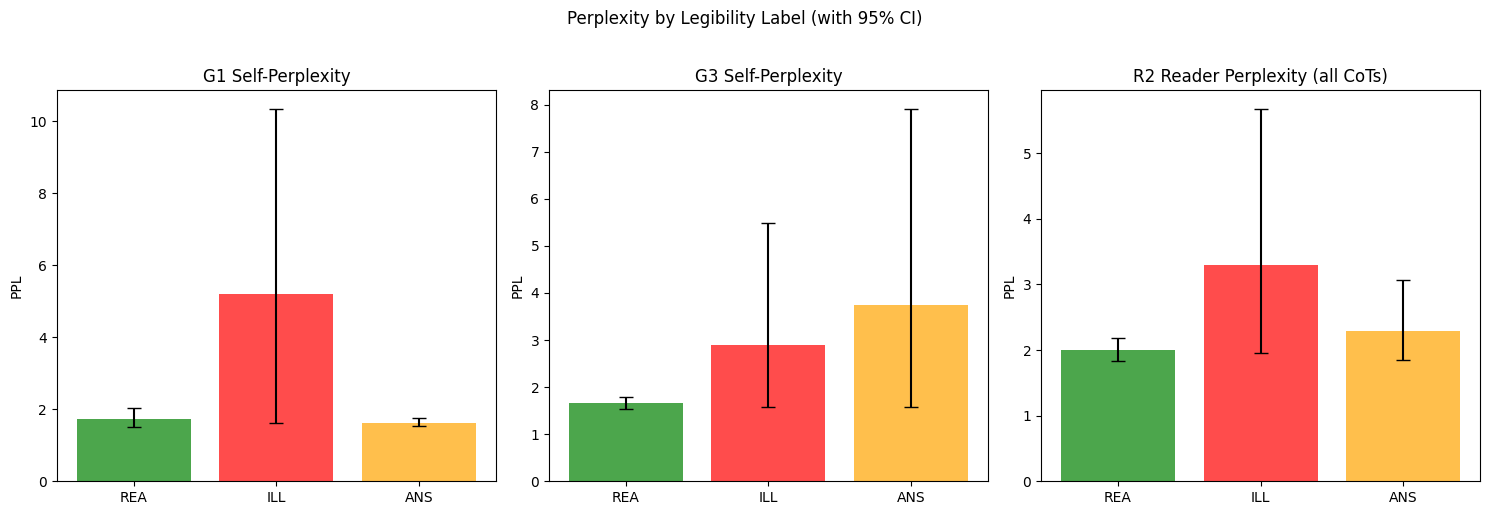


--- t-tests: REASONING_LEGIBLE vs ILLEGIBLE ---
  G1 self-PPL: t=-1.389, p=0.1670, legible_mean=1.73, illegible_mean=5.19
  G3 self-PPL: t=-0.976, p=0.3308, legible_mean=1.65, illegible_mean=2.89
  R2 reader-PPL: t=-1.254, p=0.2109, legible_mean=2.00, illegible_mean=3.29


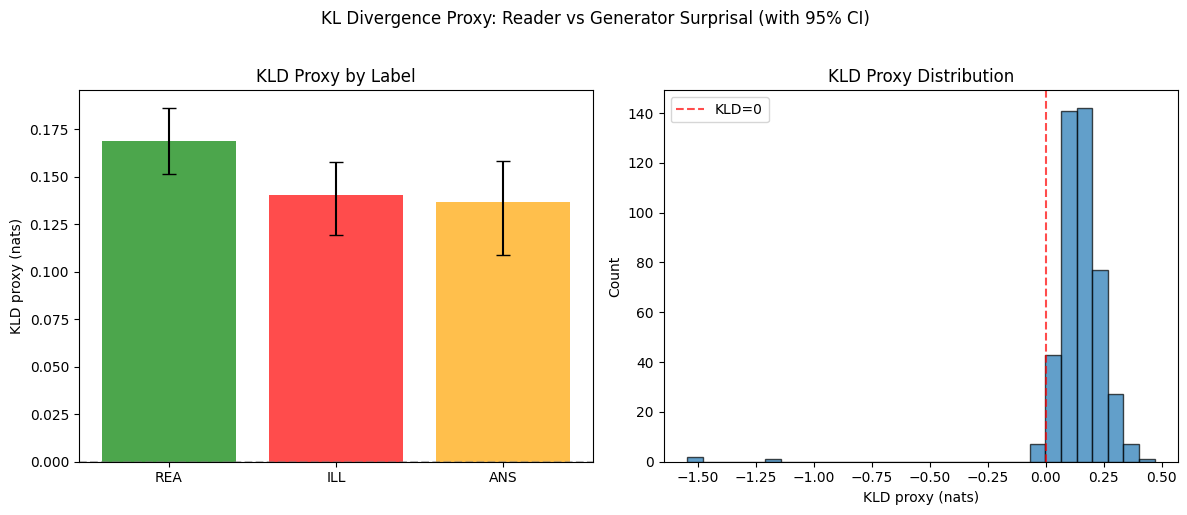


--- Sanity Checks ---
Generator self-PPL (should be LOW):  mean=3.38
Reader R2 PPL (should be HIGHER):    mean=2.82
KLD proxy (should be POSITIVE):      mean=0.143, frac>0=97.8%


In [8]:
# ===========================================================================
# Diagnostics: PPL distributions by label, t-tests, KLD plots
# ===========================================================================
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. Reader PPL by legibility label ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax_idx, (gen_name, gen_cots, gen_ppls, gen_labels) in enumerate([
    ("G1", all_cots_g1, g1_ppls, g1_labels),
    ("G3", all_cots_g3, [r['perplexity'] for r in g3_results], [c['label'] for c in all_cots_g3]),
]):
    ax = axes[ax_idx]
    for label, color in [('REASONING_LEGIBLE', 'green'), ('ILLEGIBLE', 'red'), ('ANSWER_LEAKED', 'orange')]:
        mask = [l == label for l in gen_labels]
        subset = [p for p, m in zip(gen_ppls, mask) if m]
        if subset:
            mean_val, ci_lo, ci_hi = bootstrap_ci_metric(np.array(subset))
            ax.bar(label[:3], mean_val, yerr=[[mean_val - ci_lo], [ci_hi - mean_val]],
                   color=color, alpha=0.7, capsize=5)
    ax.set_title(f"{gen_name} Self-Perplexity")
    ax.set_ylabel("PPL")

# Reader PPL by label (combined)
ax = axes[2]
all_labels_combined = [c['label'] for c in all_cots_combined]
for label, color in [('REASONING_LEGIBLE', 'green'), ('ILLEGIBLE', 'red'), ('ANSWER_LEAKED', 'orange')]:
    mask = [l == label for l in all_labels_combined]
    subset = [p for p, m in zip(r2_ppls, mask) if m]
    if subset:
        mean_val, ci_lo, ci_hi = bootstrap_ci_metric(np.array(subset))
        ax.bar(label[:3], mean_val, yerr=[[mean_val - ci_lo], [ci_hi - mean_val]],
               color=color, alpha=0.7, capsize=5)
ax.set_title("R2 Reader Perplexity (all CoTs)")
ax.set_ylabel("PPL")

fig.suptitle("Perplexity by Legibility Label (with 95% CI)", y=1.02)
fig.tight_layout()
fig.savefig(PHASE2_RESULTS_DIR / "ppl_by_label.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 2. t-tests: legible vs illegible ---
print("\n--- t-tests: REASONING_LEGIBLE vs ILLEGIBLE ---")
for gen_name, gen_ppls, gen_labels in [
    ("G1 self-PPL", g1_ppls, g1_labels),
    ("G3 self-PPL", [r['perplexity'] for r in g3_results], [c['label'] for c in all_cots_g3]),
    ("R2 reader-PPL", r2_ppls, all_labels_combined),
]:
    leg_mask = [l == 'REASONING_LEGIBLE' for l in gen_labels]
    ill_mask = [l == 'ILLEGIBLE' for l in gen_labels]
    leg_ppls = [p for p, m in zip(gen_ppls, leg_mask) if m]
    ill_ppls = [p for p, m in zip(gen_ppls, ill_mask) if m]
    if len(leg_ppls) >= 5 and len(ill_ppls) >= 5:
        t_stat, p_val = stats.ttest_ind(leg_ppls, ill_ppls, equal_var=False)
        print(f"  {gen_name}: t={t_stat:.3f}, p={p_val:.4f}, "
              f"legible_mean={np.mean(leg_ppls):.2f}, illegible_mean={np.mean(ill_ppls):.2f}")
    else:
        print(f"  {gen_name}: insufficient samples (leg={len(leg_ppls)}, ill={len(ill_ppls)})")

# --- 3. KLD proxy distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for label, color in [('REASONING_LEGIBLE', 'green'), ('ILLEGIBLE', 'red'), ('ANSWER_LEAKED', 'orange')]:
    mask = [c['label'] == label for c in all_cots_combined]
    subset_kld = [k for k, m in zip(kld_proxies, mask) if m]
    if subset_kld:
        mean_val, ci_lo, ci_hi = bootstrap_ci_metric(np.array(subset_kld))
        ax.bar(label[:3], mean_val, yerr=[[mean_val - ci_lo], [ci_hi - mean_val]],
               color=color, alpha=0.7, capsize=5)
ax.set_title("KLD Proxy by Label")
ax.set_ylabel("KLD proxy (nats)")
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

ax = axes[1]
ax.hist(kld_proxies, bins=30, alpha=0.7, edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='KLD=0')
ax.set_xlabel("KLD proxy (nats)")
ax.set_ylabel("Count")
ax.set_title("KLD Proxy Distribution")
ax.legend()

fig.suptitle("KL Divergence Proxy: Reader vs Generator Surprisal (with 95% CI)", y=1.02)
fig.tight_layout()
fig.savefig(PHASE2_RESULTS_DIR / "kld_proxy_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 4. Sanity checks ---
print("\n--- Sanity Checks ---")
gen_self_ppls = g1_ppls + [r['perplexity'] for r in g3_results]
print(f"Generator self-PPL (should be LOW):  mean={np.mean(gen_self_ppls):.2f}")
print(f"Reader R2 PPL (should be HIGHER):    mean={np.mean(r2_ppls):.2f}")
print(f"KLD proxy (should be POSITIVE):      mean={np.mean(kld_proxies):.3f}, "
      f"frac>0={np.mean(np.array(kld_proxies) > 0):.1%}")

In [9]:
# ===========================================================================
# Save final outputs
# ===========================================================================

# 1. Distributional shift scores (main output for downstream consumers)
ds_scores_path = PHASE2_RESULTS_DIR / "distributional_shift_scores.json"
with open(ds_scores_path, "w") as f:
    json.dump(ds_scores, f, indent=2)
print(f"Saved {len(ds_scores)} entries to {ds_scores_path}")

# 2. Generator self-perplexity with legibility labels
gen_self_ppl = {}
for i, c in enumerate(all_cots_g1):
    key = f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}"
    gen_self_ppl[key] = {
        "generator_id": c['generator_id'],
        "label": c['label'],
        "perplexity": float(g1_results[i]['perplexity']),
        "mean_logprob": float(g1_results[i]['mean_logprob']),
        "n_tokens": int(g1_results[i]['n_tokens']),
    }
for i, c in enumerate(all_cots_g3):
    key = f"{c['sample_id']}|{c['generator_id']}|{c['epoch']}"
    gen_self_ppl[key] = {
        "generator_id": c['generator_id'],
        "label": c['label'],
        "perplexity": float(g3_results[i]['perplexity']),
        "mean_logprob": float(g3_results[i]['mean_logprob']),
        "n_tokens": int(g3_results[i]['n_tokens']),
    }

gen_ppl_path = PHASE2_RESULTS_DIR / "generator_self_perplexity.json"
with open(gen_ppl_path, "w") as f:
    json.dump(gen_self_ppl, f, indent=2)
print(f"Saved {len(gen_self_ppl)} entries to {gen_ppl_path}")

print("\nNB10 complete.")

Saved 448 entries to /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/distributional_shift_scores.json
Saved 448 entries to /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/generator_self_perplexity.json

NB10 complete.
